## 1. Data Loading and Cleaning


In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\hp\Downloads\project DS\sales_analysis\SampleSuperstore.csv.zip", compression='zip')

print(df.head())
print(df.info())
print(df.describe())

        Ship Mode    Segment        Country             City       State  \
0    Second Class   Consumer  United States        Henderson    Kentucky   
1    Second Class   Consumer  United States        Henderson    Kentucky   
2    Second Class  Corporate  United States      Los Angeles  California   
3  Standard Class   Consumer  United States  Fort Lauderdale     Florida   
4  Standard Class   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region         Category Sub-Category     Sales  Quantity  \
0        42420  South        Furniture    Bookcases  261.9600         2   
1        42420  South        Furniture       Chairs  731.9400         3   
2        90036   West  Office Supplies       Labels   14.6200         2   
3        33311  South        Furniture       Tables  957.5775         5   
4        33311  South  Office Supplies      Storage   22.3680         2   

   Discount    Profit  
0      0.00   41.9136  
1      0.00  219.5820  
2      0.00    6.871

In [2]:
df.isnull().sum()

Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64

In [3]:
df.drop_duplicates(inplace=True)

In [6]:
df.columns = df.columns.str.strip()

In [9]:
df['Profit Margin'] = df['Profit'] / df['Sales']

In [8]:
print(df.columns)

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


## 2. Key Business KPIs



In [10]:
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = total_profit / total_sales

print(f"Total Sales: {total_sales:,.2f}")
print(f"Total Profit: {total_profit:,.2f}")
print(f"Overall Profit Margin: {overall_margin:.2%}")

Total Sales: 2,296,195.59
Total Profit: 286,241.42
Overall Profit Margin: 12.47%


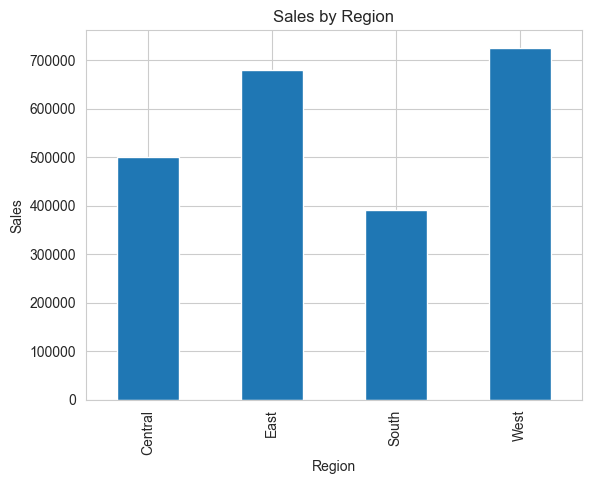

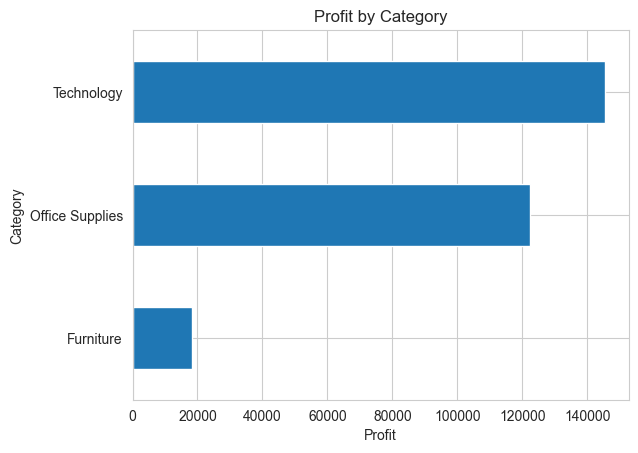

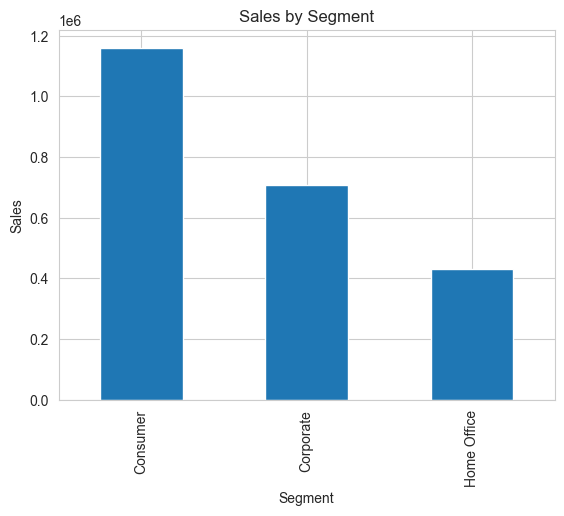

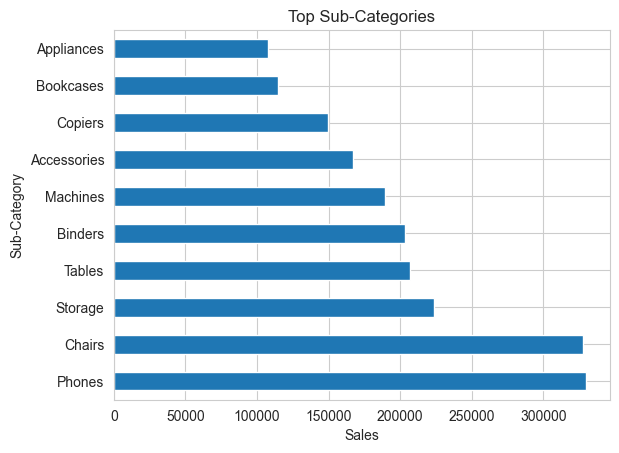

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# 1. Sales by Region
df.groupby('Region')['Sales'].sum().plot(kind='bar', title='Sales by Region')
plt.ylabel("Sales")
plt.show()

# 2. Profit by Category
df.groupby('Category')['Profit'].sum().plot(kind='barh', title='Profit by Category')
plt.xlabel("Profit")
plt.show()

# 3. Sales by Segment
df.groupby('Segment')['Sales'].sum().plot(kind='bar', title='Sales by Segment')
plt.ylabel("Sales")
plt.show()

# 4. Sales by Sub-Category (Top 10)
df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).head(10).plot(kind='barh', title='Top Sub-Categories')
plt.xlabel("Sales")
plt.show()
